# Análisis de Resultados

En este notebook se realiza el análisis comparativo de las arquitecturas de Deep Learning implementadas para la clasificación de imágenes naturales.

Los modelos evaluados fueron:

- LeNet5
- VGGMini
- ResNet18
- ResNet18 Pretrained

El análisis incluye:
- comparación de métricas,
- curvas de entrenamiento,
- matrices de confusión,
- desempeño por clase,
- y conclusiones finales.

In [10]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
RESULTS_PATH = "results"

models = [
    "lenet5",
    "vggmini",
    "resnet18",
    "resnet18_pretrained"
]

# Comparación General de Modelos

En esta sección se comparan las métricas generales de desempeño obtenidas por cada arquitectura.

In [12]:
summary_results = []

for model in models:

    summary_path = os.path.join(
        RESULTS_PATH,
        model,
        "summary.csv"
    )

    summary_df = pd.read_csv(summary_path)

    accuracy = summary_df.loc[
        summary_df["metric"] == "test_accuracy",
        "value"
    ].values[0]

    loss = summary_df.loc[
        summary_df["metric"] == "test_loss",
        "value"
    ].values[0]

    summary_results.append({
        "Model": model,
        "Accuracy": accuracy,
        "Loss": loss
    })

comparison_df = pd.DataFrame(summary_results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy,Loss
3,resnet18_pretrained,0.925667,0.220202
2,resnet18,0.859667,0.379665
1,vggmini,0.850333,0.424989
0,lenet5,0.829000,0.470024


Los resultados muestran que el modelo ResNet18_Pretrained obtuvo el mejor desempeño general, alcanzando la mayor precisión y el menor valor de pérdida.

Por otro lado, LeNet5 presentó el desempeño más bajo, lo cual era esperado debido a que es una arquitectura originalmente diseñada para problemas más simples de visión por computador.

Las arquitecturas más profundas como VGGMini y ResNet18 lograron mejorar progresivamente el desempeño gracias a una mayor capacidad de extracción de características.

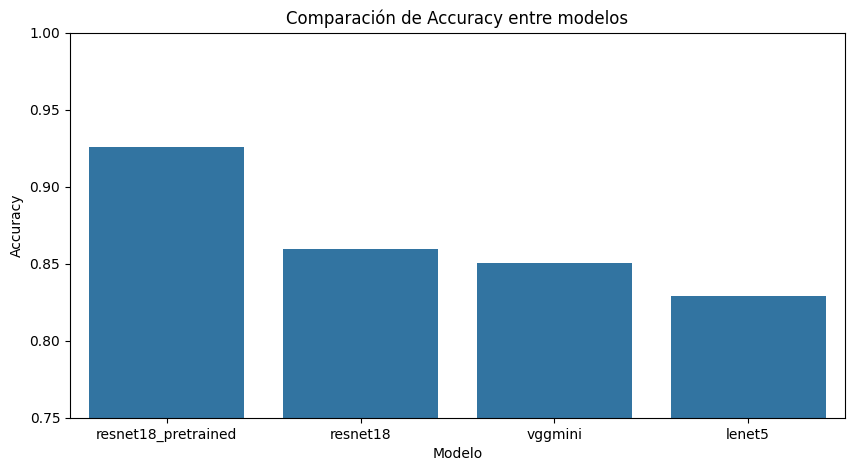

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.title("Comparación de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")

plt.ylim(0.75, 1.0)

plt.show()

# Curvas de Entrenamiento

A continuación se presentan las curvas de entrenamiento y validación para cada modelo.

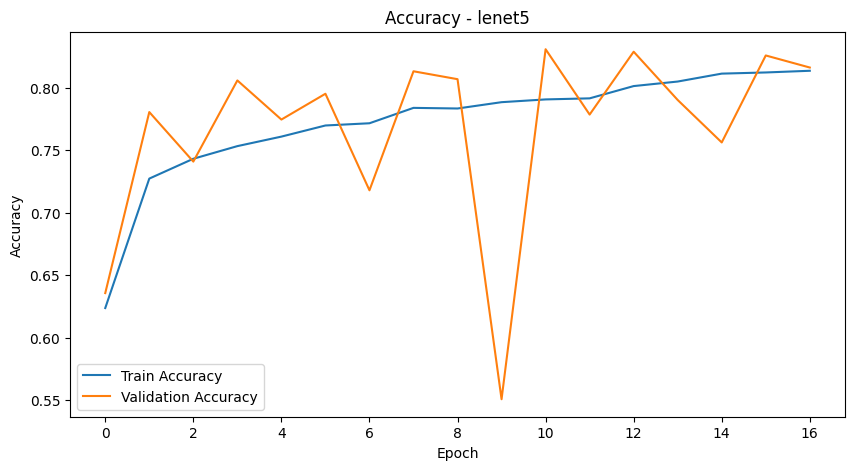

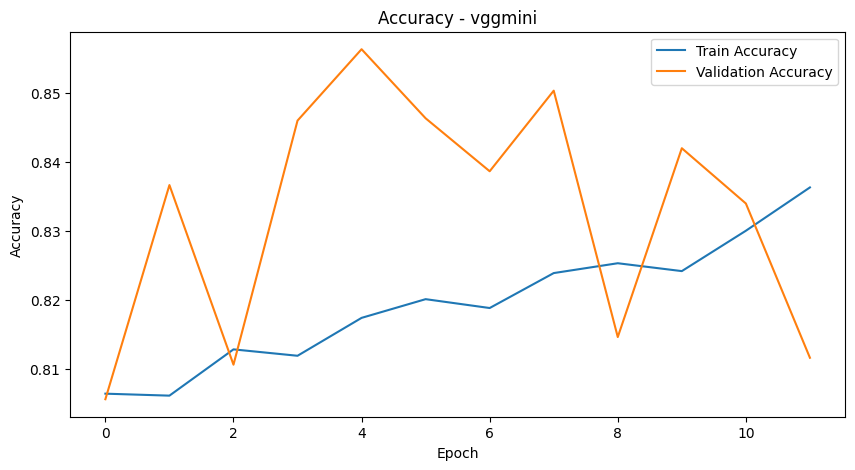

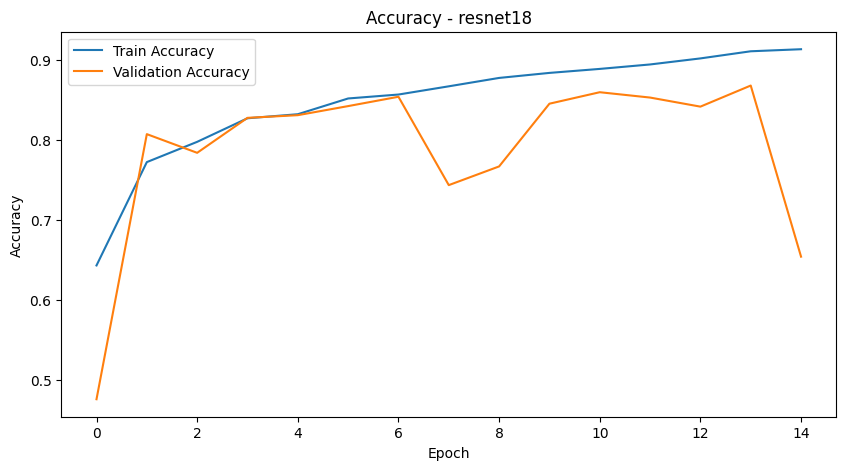

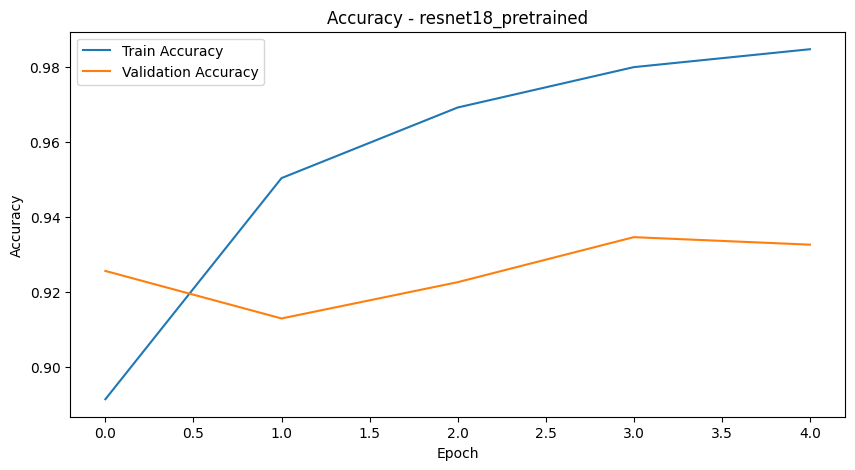

In [14]:
for model in models:

    history_path = os.path.join(
        RESULTS_PATH,
        model,
        "history.csv"
    )

    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(10,5))

    plt.plot(
        history_df["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        history_df["val_acc"],
        label="Validation Accuracy"
    )

    plt.title(f"Accuracy - {model}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

Las curvas de entrenamiento muestran diferencias importantes entre las arquitecturas evaluadas.

El modelo ResNet18_Pretrained presentó el comportamiento más estable durante el entrenamiento, manteniendo una alta precisión de validación y una diferencia reducida entre entrenamiento y validación. Esto evidencia una adecuada capacidad de generalización y confirma las ventajas del transfer learning para problemas de clasificación de imágenes.

Por otro lado, ResNet18 entrenado desde cero mostró oscilaciones más pronunciadas en la precisión de validación, lo que sugiere una mayor dificultad de optimización y posible sensibilidad a la cantidad de datos disponibles.

La arquitectura LeNet5 presentó el comportamiento más inestable, especialmente en la validación, debido a que fue originalmente diseñada para problemas más simples de visión por computador, como reconocimiento de dígitos manuscritos.

Finalmente, VGGMini logró un desempeño intermedio y relativamente estable, evidenciando que una arquitectura más profunda mejora la capacidad de extracción de características respecto a modelos clásicos como LeNet5.

# Matrices de Confusión

Las matrices de confusión permiten observar el comportamiento de clasificación de cada arquitectura y analizar las clases con mayor dificultad.

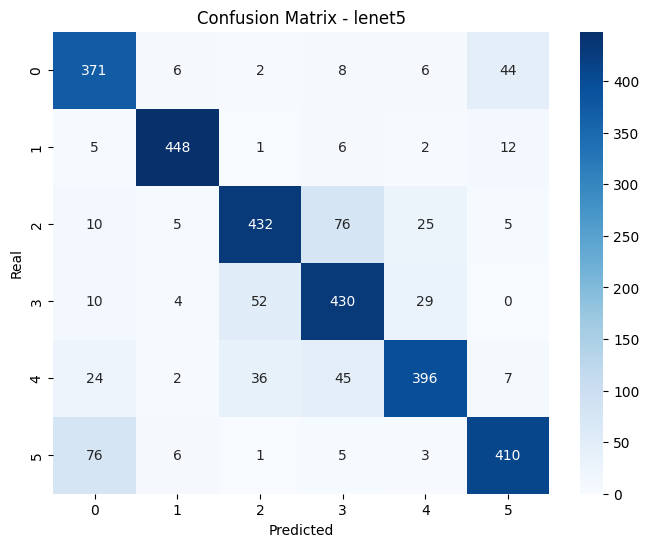

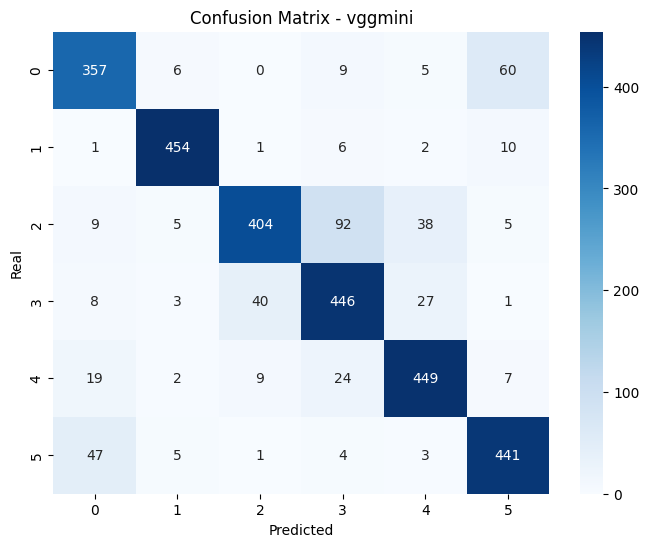

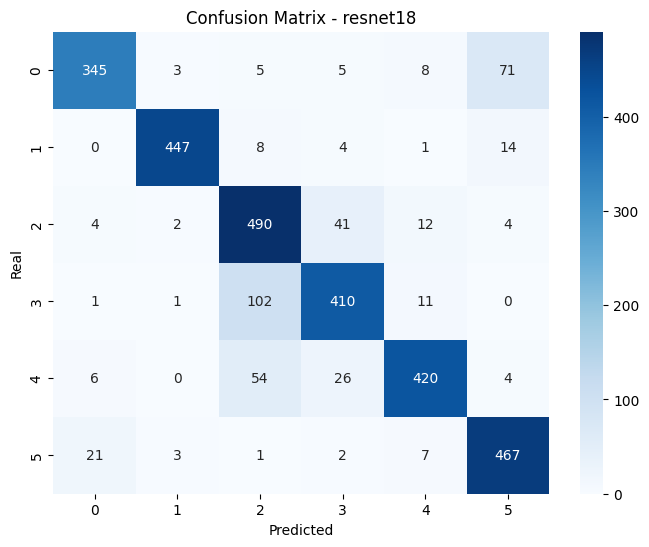

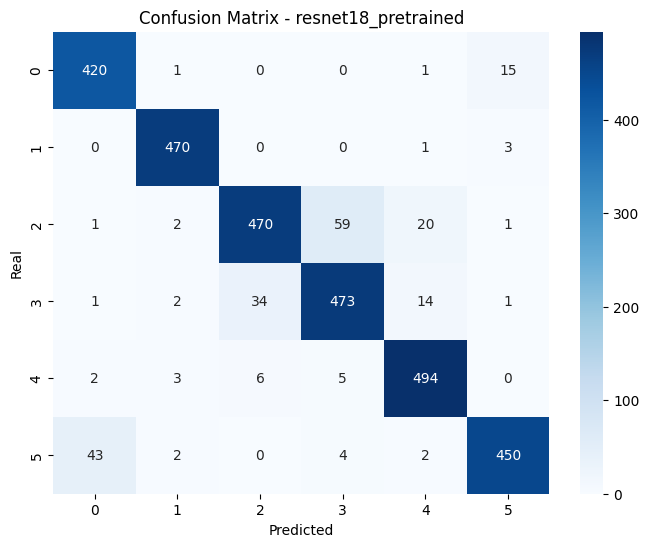

In [15]:
for model in models:

    matrix_path = os.path.join(
        RESULTS_PATH,
        model,
        "confusion_matrix.csv"
    )

    matrix_df = pd.read_csv(matrix_path)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        matrix_df,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model}")

    plt.xlabel("Predicted")
    plt.ylabel("Real")

    plt.show()

Las matrices de confusión permitieron analizar el comportamiento de cada arquitectura sobre las diferentes clases del dataset.

El modelo ResNet18_Pretrained presentó la matriz más limpia y concentrada sobre la diagonal principal, evidenciando una mayor capacidad de clasificación correcta y una reducción significativa de errores entre clases.

En contraste, LeNet5 mostró una mayor dispersión fuera de la diagonal, indicando dificultades para diferenciar ciertas categorías visualmente similares. Esto era esperado debido a que se trata de una arquitectura más simple y originalmente diseñada para imágenes menos complejas.

VGGMini y ResNet18 lograron mejorar progresivamente la separación entre clases, demostrando que arquitecturas más profundas permiten extraer representaciones visuales más robustas.

En general, las matrices de confusión confirman que el uso de arquitecturas profundas y técnicas de transferencia de aprendizaje mejora significativamente el desempeño en tareas de clasificación de imágenes naturales.

# Métricas por Clase

A continuación se presentan las métricas de precisión, recall y F1-score para cada arquitectura.

In [16]:
for model in models:

    report_path = os.path.join(
        RESULTS_PATH,
        model,
        "classification_report.csv"
    )

    report_df = pd.read_csv(report_path)

    print("="*50)
    print(f"MODELO: {model}")
    print("="*50)

    print(
        report_df[
            ["Unnamed: 0", "precision", "recall", "f1-score"]
        ].head(10)
    )

MODELO: lenet5
     Unnamed: 0  precision    recall  f1-score
0             0   0.747984  0.848970  0.795284
1             1   0.951168  0.945148  0.948148
2             2   0.824427  0.781193  0.802228
3             3   0.754386  0.819048  0.785388
4             4   0.859002  0.776471  0.815654
5             5   0.857741  0.818363  0.837589
6      accuracy   0.829000  0.829000  0.829000
7     macro avg   0.832451  0.831532  0.830715
8  weighted avg   0.832501  0.829000  0.829513
MODELO: vggmini
     Unnamed: 0  precision    recall  f1-score
0             0   0.809524  0.816934  0.813212
1             1   0.955789  0.957806  0.956797
2             2   0.887912  0.730561  0.801587
3             3   0.767642  0.849524  0.806510
4             4   0.856870  0.880392  0.868472
5             5   0.841603  0.880240  0.860488
6      accuracy   0.850333  0.850333  0.850333
7     macro avg   0.853223  0.852576  0.851178
8  weighted avg   0.853160  0.850333  0.849872
MODELO: resnet18
     Unnamed

Las métricas de precisión, recall y F1-score muestran que los modelos más profundos lograron un desempeño más balanceado entre las diferentes clases del dataset.

El modelo ResNet18_Pretrained alcanzó los mejores resultados generales, evidenciando una mayor capacidad para distinguir correctamente las distintas categorías visuales.

Las arquitecturas más simples presentaron mayores variaciones entre clases, especialmente en aquellas categorías visualmente similares, lo que sugiere limitaciones en la extracción de características complejas.

# Conclusiones Finales

En este proyecto se compararon diferentes arquitecturas de redes neuronales convolucionales para la clasificación de imágenes naturales.

Los resultados obtenidos muestran que las arquitecturas profundas con transferencia de aprendizaje presentan un desempeño superior respecto a redes entrenadas desde cero.

El modelo ResNet18_Pretrained alcanzó el mejor rendimiento general con un accuracy aproximado de 92.57% y el menor valor de pérdida, evidenciando una mejor capacidad de generalización sobre el conjunto de prueba.

Por otro lado, LeNet5 presentó el desempeño más bajo, lo cual era esperado debido a que es una arquitectura originalmente diseñada para imágenes simples y de baja complejidad como MNIST.

La incorporación de conexiones residuales en ResNet18 permitió mejorar el desempeño respecto a arquitecturas más tradicionales como LeNet5 y VGGMini.

Las curvas de entrenamiento y matrices de confusión confirmaron que los modelos más profundos lograron clasificaciones más estables y precisas.

En general, los resultados demuestran la efectividad del transfer learning para problemas de clasificación de imágenes naturales, especialmente cuando el tamaño del dataset es moderado.